# Edinburgh Airbnb — EDA Part 2: Geographic & Spatial Analysis

Uses listing latitude and longitude data to explore spatial patterns in
pricing, availability, and listing distribution across Edinburgh.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
FIGURES_DIR = "../reports/figures"

df = pd.read_csv("../data/processed/edinburgh/listings_master.csv", low_memory=False)
print(f"{len(df):,} listings loaded")

4,925 listings loaded


## Listing Density across Edinburgh

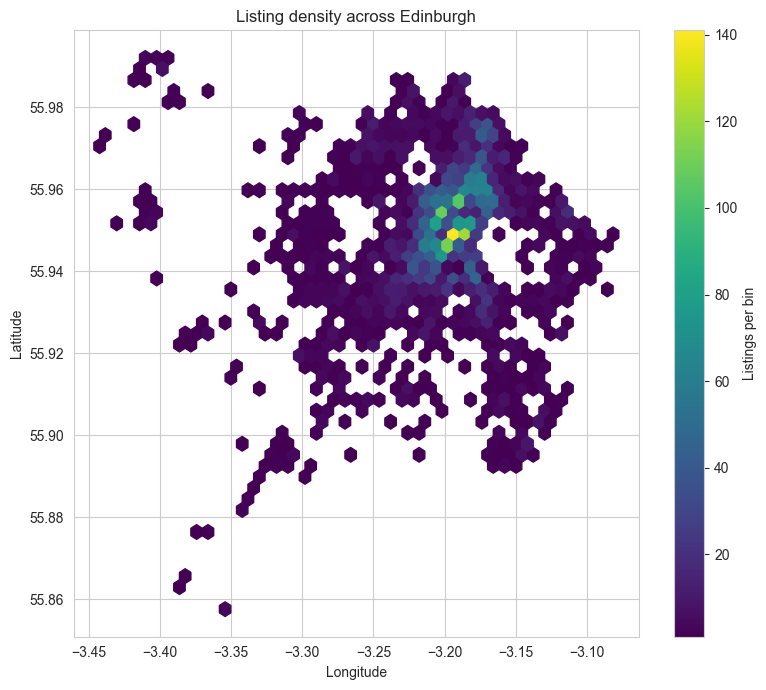

In [3]:
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(df["longitude"], df["latitude"], gridsize=45, cmap="viridis", mincnt=1)
ax.set_title("Listing density across Edinburgh")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(hb, label="Listings per bin")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig06_listing_density.png", dpi=150)
plt.show()

**Figure 6: Listing density.** Airbnb listings are concentrated in a clear hotspot around longitude -3.20 and latitude 55.95, corresponding to Edinburgh's city centre and historic core. This aligns with the neighbourhood-level results from the star schema, where areas such as Old Town, Princes Street and Leith Street (630 listings), Deans Village (326 listings), New Town West (198 listings), and New Town East and Gayfield (138 listings) had the highest listing counts. Listing density falls off rapidly outside the centre, indicating that Airbnb supply is heavily concentrated in Edinburgh's main tourist and commercial districts rather than being evenly distributed across the city.

## Price vs. distance from city centre

/Users/yasara/Documents/Projects/airbnb-analytics-platform/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/yasara/Documents/Projects/airbnb-analytics-platform/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/yasara/Documents/Projects/airbnb-analytics-platform/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


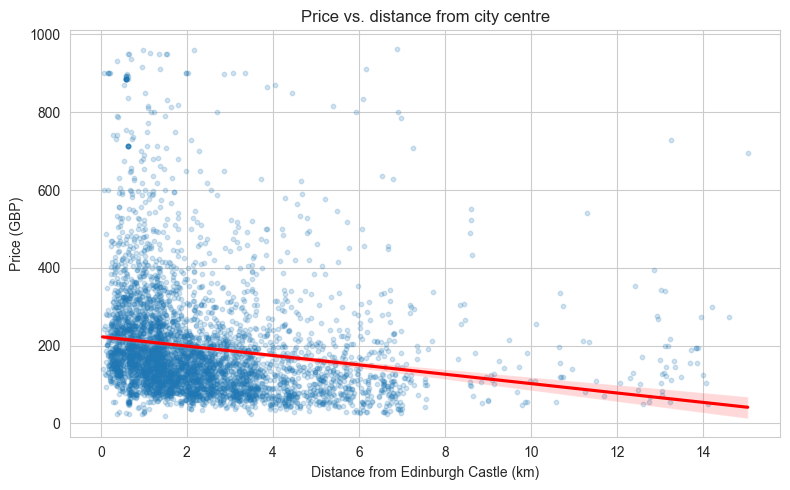

Correlation between distance from centre and price: -0.011


In [4]:
# Edinburgh Castle used as the city-centre reference point
CITY_CENTRE_LAT, CITY_CENTRE_LON = 55.9486, -3.1999


def haversine_distance_km(lat1, lon1, lat2, lon2):
    """Calculate greate-circle distance betweem two coordinates in kilometres"""
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


df["distance_from_centre_km"] = haversine_distance_km(
    df["latitude"], df["longitude"], CITY_CENTRE_LAT, CITY_CENTRE_LON
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(
    data=df[df["price_clean"] < 1000],  # cap extreme outliers for readability
    x="distance_from_centre_km", y="price_clean",
    scatter_kws={"alpha": 0.2, "s": 10}, line_kws={"color": "red"}, ax=ax,
)
ax.set_title("Price vs. distance from city centre")
ax.set_xlabel("Distance from Edinburgh Castle (km)")
ax.set_ylabel("Price (GBP)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig07_price_vs_distance.png", dpi=150)
plt.show()

correlation = df[["distance_from_centre_km", "price_clean"]].corr().iloc[0, 1]
print(f"Correlation between distance from centre and price: {correlation:.3f}")

**Figure 7: Price vs. distance from centre.** Nightly price shows a very weak negative relationship with distance from Edinburgh city centre, with a correlation of -0.011. Although the fitted trend line slopes slightly downward, the correlation is so close to zero that distance alone explains virtually none of the variation in listing prices. Expensive and inexpensive properties can be found at almost every distance from the centre.

For hosts or investors, this suggests that proximity to the city centre does not, by itself, guarantee a meaningful price premium. Other factors such as room type, property size, neighbourhood characteristics, amenities, and listing quality appear to have a much stronger influence on pricing than simple distance from Edinburgh Castle. While central locations contain many listings, city-centre proximity is not a strong standalone predictor of nightly rates in this dataset.

## Review scores, mapped spatially

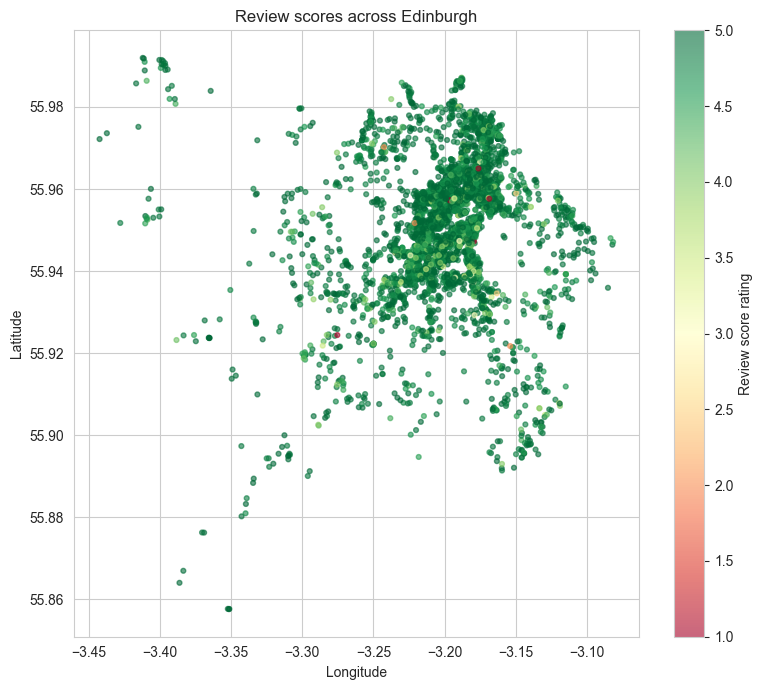

In [5]:
rated = df.dropna(subset=["review_scores_rating"])

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(
    rated["longitude"], rated["latitude"],
    c=rated["review_scores_rating"], cmap="RdYlGn", s=12, alpha=0.6,
)
ax.set_title("Review scores across Edinburgh")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(sc, label="Review score rating")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig08_review_scores_spatial.png", dpi=150)
plt.show() 

**Figure 8: Review scores, spatially.** Review scores remain consistently high across almost all parts of Edinburgh, with the map dominated by dark green points corresponding to ratings close to 5.0. This matches the distribution seen in Figure 4, where review scores were heavily concentrated at the upper end of the scale and 58.4% of rated listings scored 4.8 or above.

There are a small number of lower-rated listings visible as isolated yellow, orange, or red points, but they do not appear to form any obvious geographic clusters. Instead, lower scores are scattered throughout the city, suggesting that review quality is driven more by individual property and host characteristics than by location. Overall, there is little evidence of specific neighbourhoods consistently receiving worse guest reviews.

## Geographic clustering by property and room type

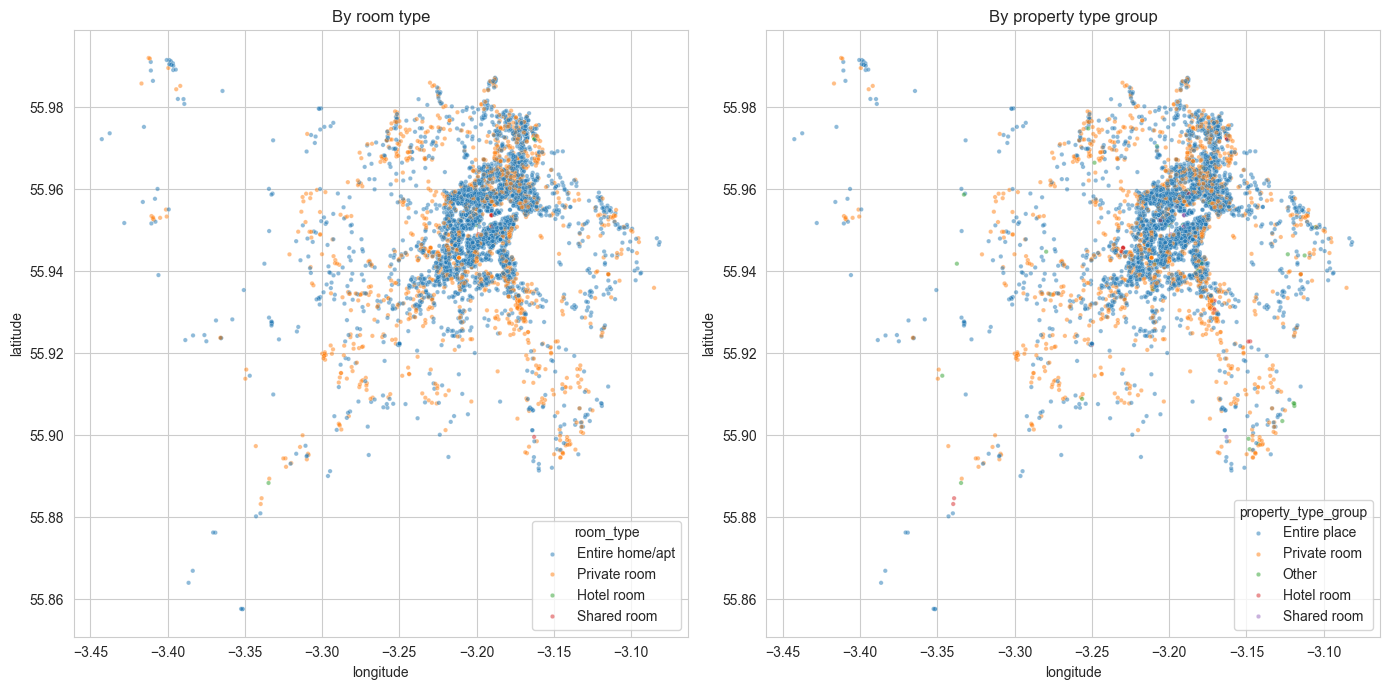

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

sns.scatterplot(
    data=df, x="longitude", y="latitude", hue="room_type",
    s=10, alpha=0.5, ax=axes[0],
)
axes[0].set_title("By room type")

sns.scatterplot(
    data=df, x="longitude", y="latitude", hue="property_type_group",
    s=10, alpha=0.5, ax=axes[1],
)
axes[1].set_title("By property type group")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig09_property_room_type_clusters.png", dpi=150)
plt.show() 

**Figure 9: Property/room type clustering.** Entire home/apartment listings dominate the central parts of Edinburgh and make up the majority of listings across most areas of the city. Private rooms are more dispersed and appear more common in residential neighbourhoods surrounding the city centre, although they remain intermingled with entire-home listings rather than forming completely separate geographic zones.

Hotel room and shared room listings are relatively rare and do not form large, clearly defined clusters in this dataset. The strongest visible pattern is the concentration of entire-home listings around the high-density central area identified in Figure 6, suggesting that short-term rental activity in Edinburgh's core tourist districts is primarily driven by entire-property rentals rather than private-room accommodation. Overall, room types are partially mixed across the city, but central neighbourhoods show a noticeably higher concentration of entire-home listings.